In [1]:
import re
import subprocess
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from bids import BIDSLayout
from nipype.interfaces.ants import ApplyTransforms
from nipype.interfaces import fsl

data_path = Path("/data/derivatives/hcph-smriprep-reliability")

## Preprocessing

Smriprep does not directly output the individual T2w image that have been corrected for intensity non-uniformity (INU). To get access to the bias-field corrected individual T2w, we copied them from smriprep work directory into `inu_corrected_individual_T2w`. Specifially, they were stored in `$WORKDIR/smriprep_wf/single_subject_001_wf/anat_preproc_wf/anat_fit_wf/t2w_template_wf/n4_correct/mapflow/_n4_correct*/*.nii.gz`. Let's first load those INU-corrected T2w images.

In [2]:
# Locate the inu-corrected individual T1w images
t2w_files = list((data_path / "inu_corrected_individual_T2w").glob("*_corrected.nii.gz"))
t2w_df = pd.DataFrame({"t2w_file": t2w_files})
t2w_df = t2w_df.assign(session=t2w_df["t2w_file"].astype(str).str.extract(r'ses-(\d+)')[0])

# Load the template T2w image
ref_t2w = list((data_path / "inu_corrected_individual_T2w").glob("*_template.nii.gz"))[0]
ref_t2w_img = nib.load(ref_t2w)

# The T2w scan was not acquired in ses-024
assert len(t2w_files) == 35

print(t2w_df.head())

                                            t2w_file session
0  /data/derivatives/hcph-smriprep-reliability/in...     022
1  /data/derivatives/hcph-smriprep-reliability/in...     005
2  /data/derivatives/hcph-smriprep-reliability/in...     007
3  /data/derivatives/hcph-smriprep-reliability/in...     019
4  /data/derivatives/hcph-smriprep-reliability/in...     028


So that the voxel are aligned across sessions, we will use the transformation computed by smriprep to register the T2w images into a common space. Smriprep does not directly output the transforms but we copied them from smriprep work directory into `inu_corrected_individual_T2w`. Specifially, they were stored in `$WORKDIR/smriprep_wf/single_subject_001_wf/anat_preproc_wf/anat_fit_wf/t2w_template_wf/concat_xfms/mapflow/_concat_xfms*/out_fwd.tfm`. The code I used to copy the transformation files can be found under `code/analysis/smriprep-copy-xfms.sh`.

In [3]:
# Locate the transformation to register images to the reference T1w
transform_files = list((data_path / "inu_corrected_individual_T2w").glob("*_xfm.txt"))
transform_df = pd.DataFrame({"transform_file": transform_files})
transform_df = transform_df.assign(session=transform_df["transform_file"].astype(str).str.extract(r'ses-(\d+)')[0])
assert len(transform_files) == 35

t2w_df = pd.merge(t2w_df, transform_df, on="session", how="inner")
assert len(t2w_df) == 35
print(t2w_df.head())

                                            t2w_file session  \
0  /data/derivatives/hcph-smriprep-reliability/in...     022   
1  /data/derivatives/hcph-smriprep-reliability/in...     005   
2  /data/derivatives/hcph-smriprep-reliability/in...     007   
3  /data/derivatives/hcph-smriprep-reliability/in...     019   
4  /data/derivatives/hcph-smriprep-reliability/in...     028   

                                      transform_file  
0  /data/derivatives/hcph-smriprep-reliability/in...  
1  /data/derivatives/hcph-smriprep-reliability/in...  
2  /data/derivatives/hcph-smriprep-reliability/in...  
3  /data/derivatives/hcph-smriprep-reliability/in...  
4  /data/derivatives/hcph-smriprep-reliability/in...  


In [4]:
output_path = data_path / "t2w_before_alignment_4d.nii.gz"
if not output_path.exists():
    t2w_list = []
    for file in t2w_df["t2w_file"]:
        img = nib.load(file)
        t2w = img.get_fdata()
        t2w_list.append(t2w)

    t2w_list = np.transpose(np.array(t2w_list), (1, 2, 3, 0))
    # Save the 4D image containing all the T1w images as a NIfTI file
    t2w_4d_img = nib.Nifti1Image(t2w_list, ref_t2w_img.affine, ref_t2w_img.header)

    nib.save(t2w_4d_img, output_path)
    print(f"4D T1w image saved to {output_path}")

In [5]:
# Apply the transformation to each T1w image
for index, row in t2w_df.iterrows():  
    # Set up the ApplyTransforms interface
    output_file = str(row['t2w_file']).replace(".nii.gz", "_aligned.nii.gz")
    if not Path(output_file).exists():
        at = ApplyTransforms()
        at.inputs.input_image = str(row['t2w_file'])
        at.inputs.transforms = str(row['transform_file'])
        at.inputs.reference_image = ref_t2w
        at.inputs.output_image = str(row['t2w_file']).replace(".nii.gz", "_aligned.nii.gz")
        
        # Run the transformation
        result = at.run()
        print(f"Transformation applied for session {row['session']}, output saved to {output_file}")

Smriprep does not compute the segmentation on the T2w template, so we will run it separately here using FSL FAST. Before running segmentation, I skull-stripped the brain using Synthstrip docker wrapper (see the command below)

```
curl -O https://raw.githubusercontent.com/freesurfer/freesurfer/dev/mri_synthstrip/synthstrip-docker
chmod +x synthstrip-docker
./synthstrip-docker -i /data/derivatives/hcph-smriprep-reliability/inu_corrected_individual_T2w/sub-001_ses-001_acq-original_T2w_noise_corrected_ras_template.nii.gz -o /data/derivatives/hcph-smriprep-reliability/inu_corrected_individual_T2w/sub-001_ses-001_acq-original_T2w_noise_corrected_ras_template_skullstripped.nii.gz -t 24

```

In [6]:
## Skull-stripping
skullstripped_t2w_path = data_path / "inu_corrected_individual_T2w" / 'sub-001_ses-001_acq-original_T2w_noise_corrected_ras_template_skullstripped.nii.gz'
if not skullstripped_t2w_path.exists():
    raise FileNotFoundError(f"Skull-stripped T2w template not found at {skullstripped_t2w_path}. Please generate it following the command indicated above.")

## Segmentation
seg_path = data_path / "inu_corrected_individual_T2w"/ "fast_seg.nii.gz"
if not seg_path.exists():
    # Run FAST on the T2w template
    fast = fsl.FAST()
    fast.inputs.in_files = str(skullstripped_t2w_path)
    fast.inputs.out_basename = 'fast'
    fast.inputs.img_type = 2
    print(fast.cmdline)
    result = fast.run()

In [7]:
# Load segmentation files
gm_seg_file = list((data_path / "inu_corrected_individual_T2w").glob("*_pve_0.nii.gz"))[0]
gm_seg = nib.load(gm_seg_file).get_fdata()
wm_seg_file = list((data_path / "inu_corrected_individual_T2w").glob("*_pve_1.nii.gz"))[0]
wm_seg = nib.load(wm_seg_file).get_fdata()
csf_seg_file = list((data_path / "inu_corrected_individual_T2w").glob("*_pve_2.nii.gz"))[0]
csf_seg = nib.load(csf_seg_file).get_fdata()

# Binarize the probability maps
thresh = 0.6
wm_seg = wm_seg > thresh
gm_seg = gm_seg > thresh
csf_seg = csf_seg > thresh

assert np.array_equal(np.unique(wm_seg), [0, 1]), "wm_seg is not binary"
assert np.array_equal(np.unique(gm_seg), [0, 1]), "gm_seg is not binary"
assert np.array_equal(np.unique(csf_seg), [0, 1]), "csf_seg is not binary"

# Locate the aligned T1w images
t2w_aligned_files = list((data_path / "inu_corrected_individual_T2w").glob("*_aligned.nii.gz"))
assert len(t2w_aligned_files) == 35

# Apply the masks to the aligned T1w images
t2w_aligned = []
t2w_wm = []
t2w_gm = []
t2w_csf = []
for file in t2w_aligned_files:
    img = nib.load(file)
    t2w = img.get_fdata()
    t2w_aligned.append(t2w)

    assert t2w.shape == wm_seg.shape
    assert t2w.shape == gm_seg.shape
    assert t2w.shape == csf_seg.shape

    t2w_wm.append(np.multiply(t2w, wm_seg))
    t2w_gm.append(np.multiply(t2w, gm_seg))
    t2w_csf.append(np.multiply(t2w, csf_seg))

assert len(t2w_aligned) == 35
assert t2w_wm[0].shape == wm_seg.shape

# Convert to numpy arrays
t2w_wm = np.array(t2w_wm)
t2w_gm = np.array(t2w_gm)
t2w_csf = np.array(t2w_csf)


In [8]:
output_path = data_path / "t2w_aligned_4d.nii.gz"
if not output_path.exists():
    # Save the 4D image containing all the T1w images as a NIfTI file
    t2w_aligned = np.transpose(np.array(t2w_aligned), (1, 2, 3, 0))
    t2w_4d_img = nib.Nifti1Image(t2w_aligned, ref_t2w_img.affine, ref_t2w_img.header)

    nib.save(t2w_4d_img, output_path)
    print(f"4D T1w image saved to {output_path}")

4D T1w image saved to /data/derivatives/hcph-smriprep-reliability/t2w_aligned_4d.nii.gz


Quality Control: Now that we applied the transformation and wrote down the resulting image, verify using brain imaging visualization tool that the images are well aligned, by scrolling through the volumes of the 4D image.

In [9]:
# Compute the coefficient of variation to assess reliability
cov_wm = np.std(t2w_wm, axis=0) / np.mean(t2w_wm, axis=0)
cov_gm = np.std(t2w_gm, axis=0) / np.mean(t2w_gm, axis=0)
cov_csf = np.std(t2w_csf, axis=0) / np.mean(t2w_csf, axis=0)

/tmp/ipykernel_198831/2870748516.py:2: RuntimeWarning: invalid value encountered in divide
  cov_wm = np.std(t2w_wm, axis=0) / np.mean(t2w_wm, axis=0)
/tmp/ipykernel_198831/2870748516.py:3: RuntimeWarning: invalid value encountered in divide
  cov_gm = np.std(t2w_gm, axis=0) / np.mean(t2w_gm, axis=0)
/tmp/ipykernel_198831/2870748516.py:4: RuntimeWarning: invalid value encountered in divide
  cov_csf = np.std(t2w_csf, axis=0) / np.mean(t2w_csf, axis=0)


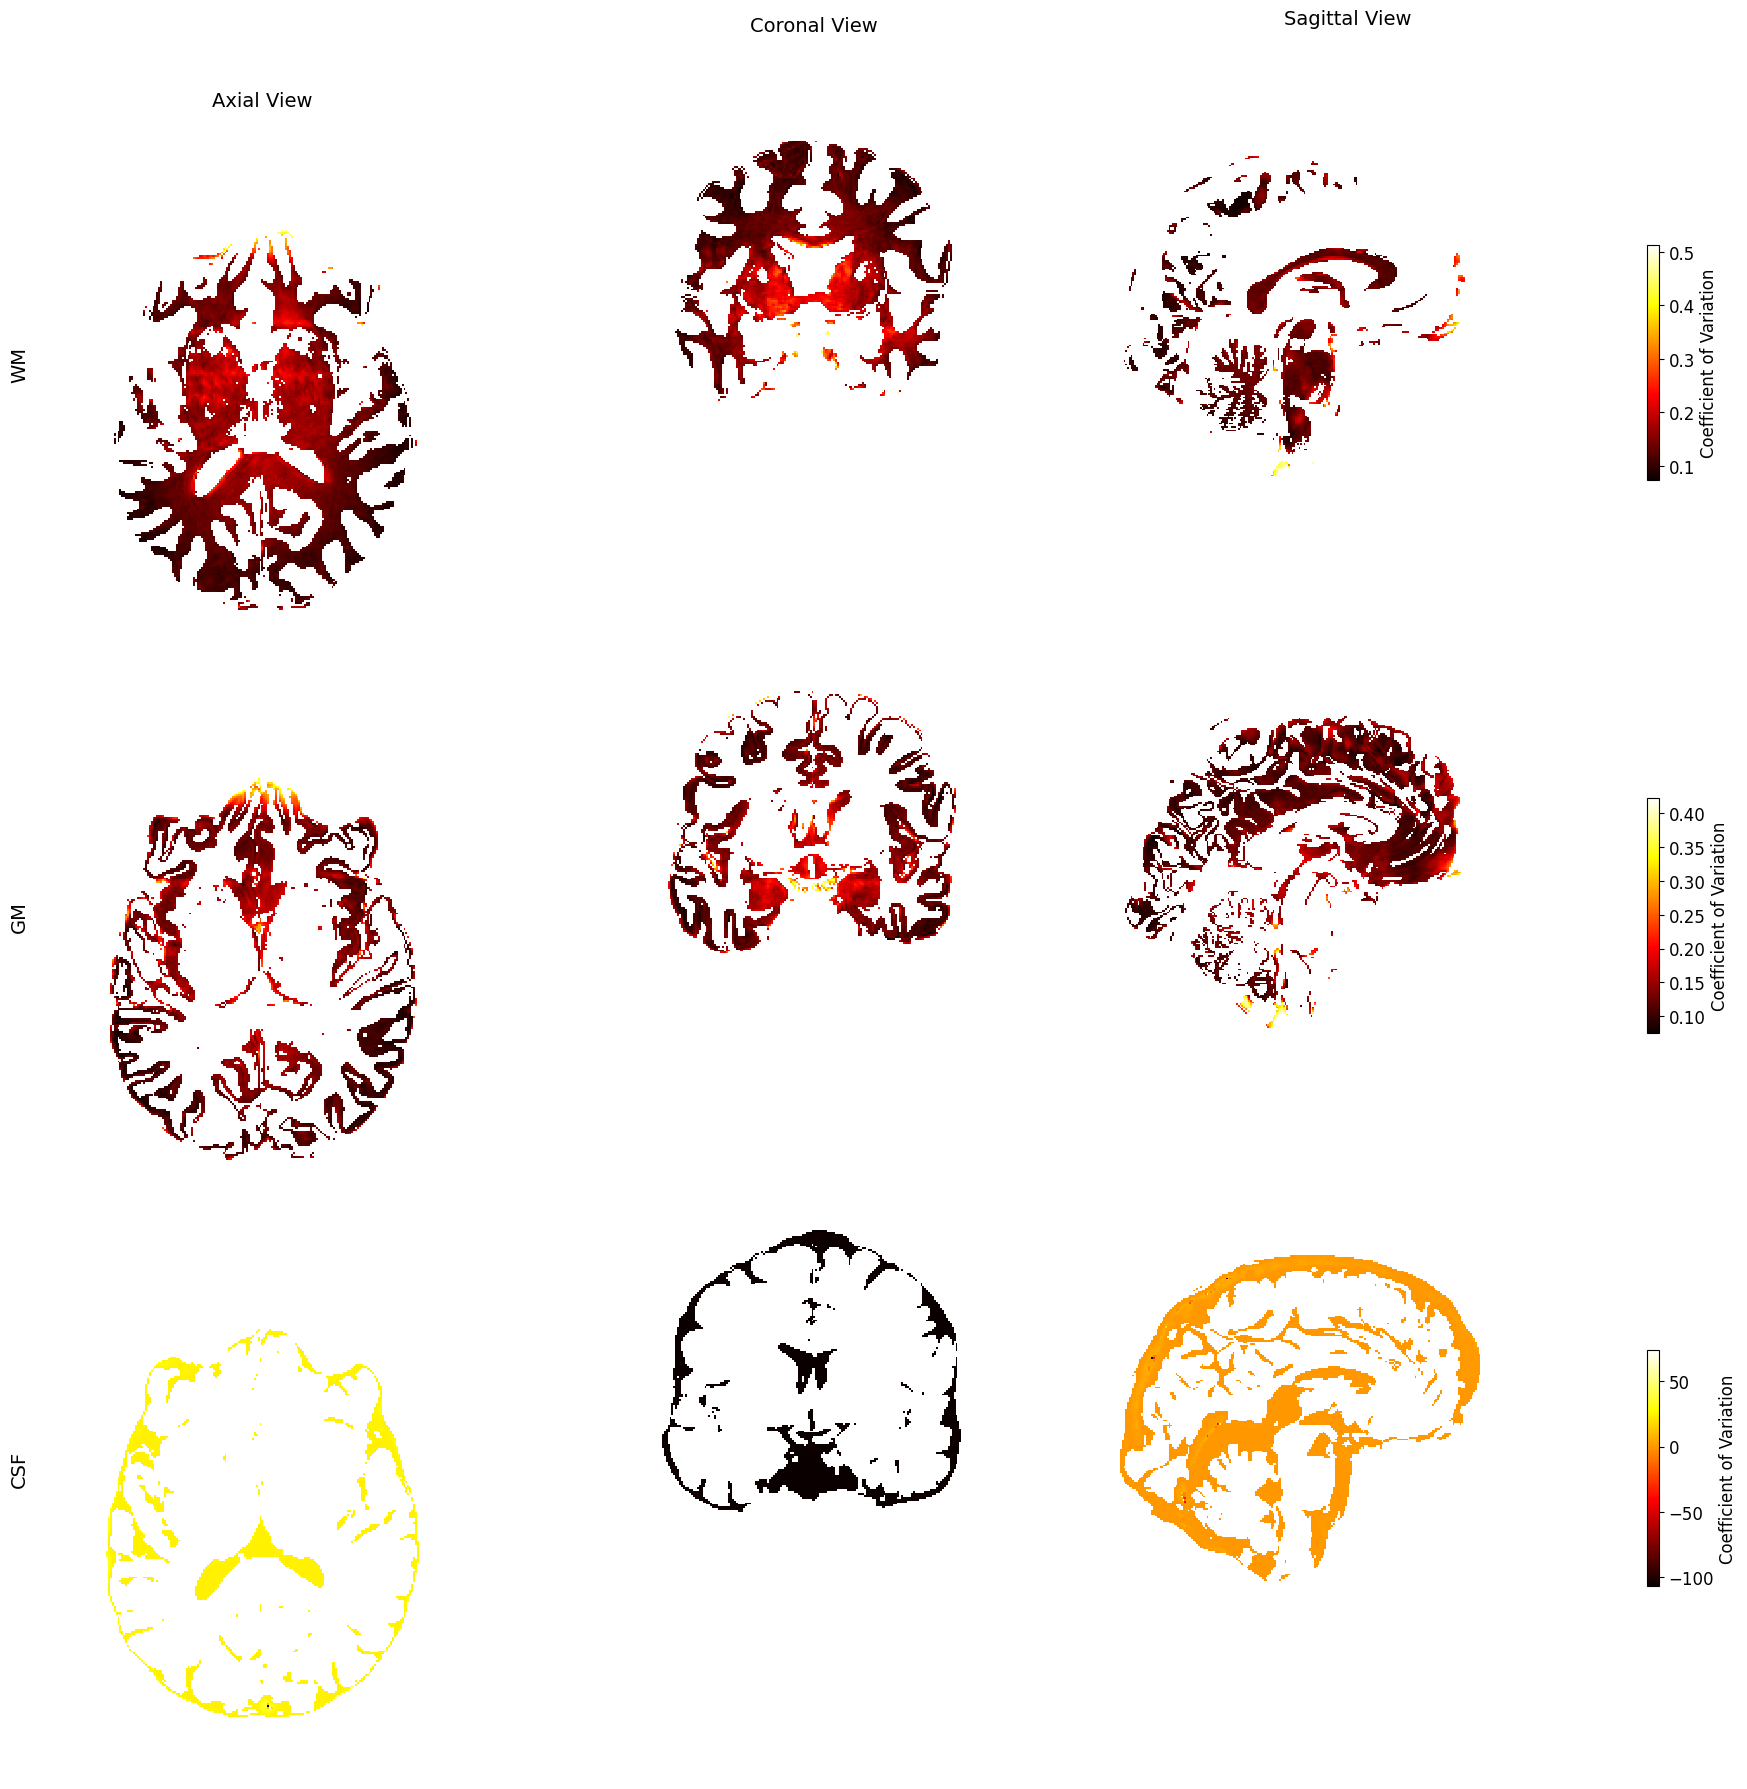

In [10]:
#vmax = [0.18, 0.25, 0.5]
y_title = [20, -19, -45]
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
slices = [
    [
        np.rot90(cov[:, :, 195], k=1),
        np.rot90(cov[:, cov.shape[2] // 2, :], k=1),
        np.rot90(cov[cov.shape[0] // 2, :, :], k=1)
    ]
    for cov in [cov_wm, cov_gm, cov_csf]
]
titles = ["Axial View", "Coronal View", "Sagittal View"]
y_labels = ["WM", "GM", "CSF"]

for i, (cov_slices, y_label) in enumerate(zip(slices, y_labels)):
    for j, (slice_, title) in enumerate(zip(cov_slices, titles)):
        ax = axes[i, j]
        #im = ax.imshow(slice_, cmap="hot", interpolation="nearest", vmax=vmax[i], vmin=0.08)
        im = ax.imshow(slice_, cmap="hot", interpolation="nearest")
        ax.text(slice_.shape[1] // 2, y_title[j], title if i == 0 else "", 
            fontsize=14, horizontalalignment='center', verticalalignment='top')
        ax.text(-10, slice_.shape[0] // 2, y_label if j == 0 else "", 
            fontsize=14, rotation=90, verticalalignment='center')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('off')
        if j == 2:
            cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.02, pad=0.04, label="Coefficient of Variation")
            cbar.ax.tick_params(labelsize=12, labelrotation=0)
            cbar.set_label("Coefficient of Variation", fontsize=12)

plt.tight_layout(h_pad=-5)  # Reduce vertical space between subplots
plt.show()

    # Save the coefficient of variation as a NIfTI file
    #cov_img = nib.Nifti1Image(cov, ref_t2w_img.affine, ref_t2w_img.header)

    #from nilearn.plotting import plot_anat
    #plot_anat(cov_img, cmap="hot", vmax=vmax[i], vmin=0.08, colorbar=True, cut_coords=(0, 0, 0), title="Coefficient of Variation", display_mode="ortho")

## !! Careful when interpreting the coefficient of variation !!

Our T2-weighted sequence was not quantitative, so we cannot assume that the T2-weighted signal intensity in each voxel remains consistent across sessions.